In [ ]:
print("Garbage Classification Project Started !")

Garbage Classification Project Started !


In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
print("TensorFlow version :", tf.__version__)

TensorFlow version : 2.20.0


In [ ]:
!wget -q https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip

In [ ]:
!wget -q https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip

In [ ]:
!unzip -q dataset-resized.zip -d garbage_dataset

In [ ]:
import os
print(os.listdir("garbage_dataset/dataset-resized"))

['trash', '.DS_Store', 'paper', 'cardboard', 'metal', 'plastic', 'glass']


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

DATASET_PATH = "garbage_dataset/dataset-resized"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Garbage Categories:")
print(class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Garbage Categories:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset is ready for training!")

Dataset is ready for training!


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Pretrained AI model loaded!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Pretrained AI model loaded!


In [ ]:
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./127.5, offset=-1),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),

    layers.Dense(6, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 502ms/step - accuracy: 0.5781 - loss: 1.1202 - val_accuracy: 0.7683 - val_loss: 0.6712
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.7710 - loss: 0.6209 - val_accuracy: 0.8040 - val_loss: 0.5495
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.8323 - loss: 0.4903 - val_accuracy: 0.8099 - val_loss: 0.5248
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8561 - loss: 0.4299 - val_accuracy: 0.8178 - val_loss: 0.4745
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8704 - loss: 0.3919 - val_accuracy: 0.8416 - val_loss: 0.4331
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.8907 - loss: 0.3307 - val_accuracy: 0.8416 - val_loss: 0.4362
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9050 - loss: 0.3071 - val_accuracy: 0.8416 - val_loss: 0.4254
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9060 - loss: 0.2819 - val_accuracy:

In [ ]:
model.save("garbage_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2026-09-11 at 2.29.10 PM.jpeg to WhatsApp Image 2026-09-11 at 2.29.10 PM.jpeg


In [ ]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Load and resize image
img = load_img(image_path, target_size=(224, 224))

# Convert image to numbers
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
predictions = model.predict(img_array)

# Find the highest probability
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

print("Prediction:", predicted_class)
print("Confidence: {:.2f}%".format(confidence))

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediction: metal
Confidence: 55.64%


In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array

# Load trained model
model = tf.keras.models.load_model("/content/drive/MyDrive/garbage_classifier.keras")

# Categories
class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

# Disposal information
disposal_info = {
    "cardboard": "♻️ Recyclable — keep it clean and dry.",
    "glass": "♻️ Recyclable — place glass in the appropriate recycling container.",
    "metal": "♻️ Recyclable — clean metal cans before recycling.",
    "paper": "♻️ Recyclable — keep paper clean and dry.",
    "plastic": "♻️ Recyclable — check local recycling rules.",
    "trash": "🗑️ General waste — dispose of it in the appropriate waste bin."
}

def classify_garbage(image):

    # Resize image
    image = image.resize((224, 224))

    # Convert image to array
    img_array = img_to_array(image)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)[0]

    # Get highest prediction
    index = np.argmax(predictions)

    category = class_names[index]
    confidence = float(predictions[index] * 100)

    result = f"{category.upper()} — {confidence:.2f}% confidence"

    advice = disposal_info[category]

    return result, advice


# Create interface
with gr.Blocks(title="Smart Garbage Classifier") as app:

    gr.Markdown(
        """
        # ♻️ Smart Garbage Classifier
        ### AI-Based Waste Classification System

        Upload an image of garbage and our AI model will classify it.
        """
    )

    image_input = gr.Image(
        type="pil",
        label="📷 Upload Garbage Image"
    )

    classify_button = gr.Button(
        "🔍 Classify Garbage"
    )

    prediction_output = gr.Textbox(
        label="🤖 AI Prediction"
    )

    disposal_output = gr.Textbox(
        label="♻️ Disposal Recommendation"
    )

    classify_button.click(
        fn=classify_garbage,
        inputs=image_input,
        outputs=[prediction_output, disposal_output]
    )

    gr.Markdown(
        """
        ---
        **Project:** AI-Based Garbage Classification
        **Model:** MobileNetV2 Transfer Learning
        **Classes:** Cardboard, Glass, Metal, Paper, Plastic, Trash
        """
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c19bcc4667b5dd71be.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model = tf.keras.models.load_model('/content/drive/MyDrive/garbage_classifier.keras')

In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'garbage_classifier.keras':
            print(os.path.join(root, file))

/content/drive/MyDrive/garbage_classifier.keras


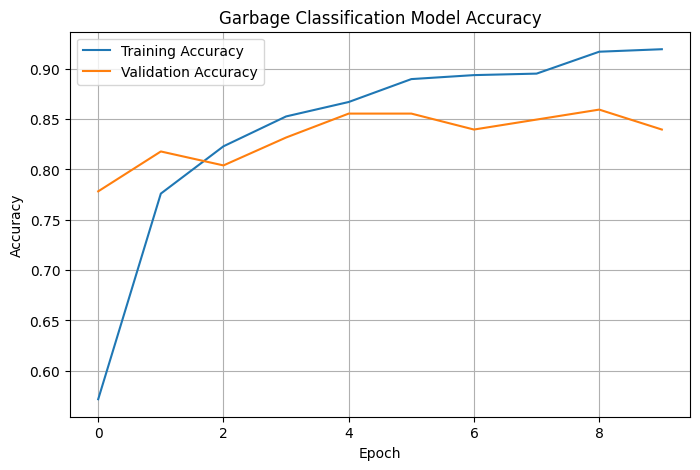

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Garbage Classification Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

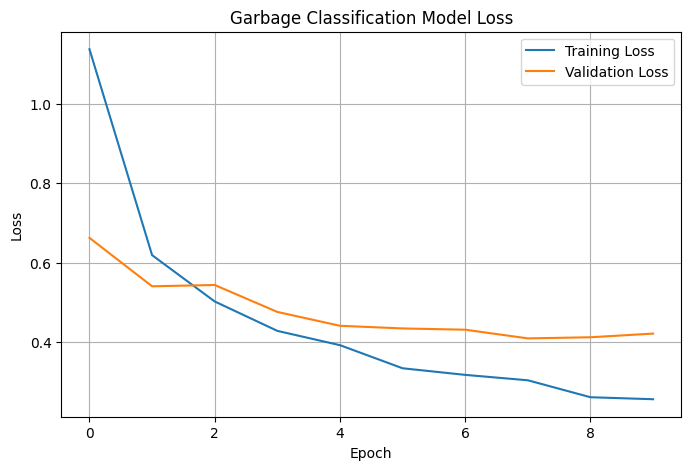

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Garbage Classification Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Final Validation Accuracy:", round(accuracy * 100, 2), "%")
print("Final Validation Loss:", round(loss, 4))

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 255ms/step - accuracy: 0.8396 - loss: 0.4209
Final Validation Accuracy: 83.96 %
Final Validation Loss: 0.4209


In [ ]:
model.save("garbage_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.97      0.87      0.92        83
       glass       0.77      0.93      0.85       103
       metal       0.94      0.76      0.84        78
       paper       0.81      0.94      0.87       124
     plastic       0.83      0.70      0.76        88
       trash       0.72      0.62      0.67        29

    accuracy                           0.84       505
   macro avg       0.84      0.80      0.82       505
weighted avg       0.85      0.84      0.84       505



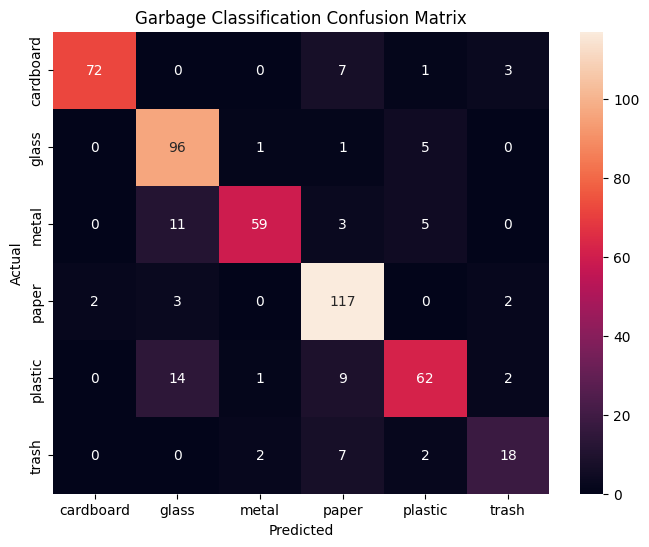

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Garbage Classification Confusion Matrix")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp garbage_classifier.keras "/content/drive/MyDrive/garbage_classifier.keras"